In [1]:
from WP.optimality_from_banditWP import Optimality
import numpy as np
from task import probabilistic_task
import torch

np.random.seed(0)

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


In [7]:
# time estimation
from tqdm import tqdm
all_times = []

opt = Optimality(
    probabilistic_task(),
)

for index in tqdm(range(30)):

    # learn task A
    import time
    np.random.seed(index)
    torch.manual_seed(index)
    opt.env.generate_test_task(num_tasks=100, num_trials=500)
    start_time = time.time()
    result = opt.infer(nb_particles=100, w_emission=True)
    end_time = time.time()
    all_times.append(end_time - start_time)

print(f"Time taken: mean {np.mean(all_times)} seconds, std {np.std(all_times)} seconds")

100%|██████████| 30/30 [5:03:52<00:00, 607.76s/it]

Time taken: mean 606.8829283555349 seconds, std 85.04769785390589 seconds


In [2]:
self = Optimality(
    probabilistic_task(),
)

In [10]:
# performances as a function of the sequence length
nb_agents = 30
nb_simuls = 100
association_probs = np.zeros((nb_agents, nb_simuls, 500, 4))
chosen_correct = np.zeros((nb_agents, nb_simuls, 500))
association_probs_reversals = np.zeros((nb_agents, nb_simuls, 500, 4))
ground_truth_probas_reversals = np.zeros((nb_agents, nb_simuls, 500, 4))
chosen_correct_reversals = np.zeros((nb_agents, nb_simuls, 500))
itrial = 300

for idx_agent in range(nb_agents):
    # generate data
    np.random.seed(idx_agent)
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=500, num_steps=5, probas=None, variable_length=False, tau=0.0)
    initial_probas = self.env.probas.copy()
    env_probas = np.zeros([nb_simuls, 500, 4])
    for i in range(nb_simuls):
        np.random.seed(i)
        env_probas[i] = self.env.probas[i, 0]
        while True:
            if (env_probas[i, 0] != env_probas[i, -1]).any():
                break
            env_probas[i, itrial:] = env_probas[i, 0][np.random.choice(np.arange(4), replace=False, size=4)]

    np.random.seed(idx_agent)
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=500, num_steps=5, probas=env_probas, variable_length=False)
    all_map_particles, prediction_weather, association_probs_trials, polarity_particles = self.infer(nb_particles=100, w_emission=False, gamma=0.5)
    chosen_correct_reversals[idx_agent] = (np.argmax(prediction_weather, axis=-1) == self.env.correct_weather.numpy())

    # psychometric curve
    np.random.seed(idx_agent)
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=500, num_steps=5, probas=initial_probas, variable_length=False, tau=0.0)
    all_map_particles, prediction_weather, association_probs_trials, polarity_particles = self.infer(nb_particles=100, w_emission=False, gamma=0.5)
    index_sorted = np.argsort(np.unique(self.env.probas, axis=1).squeeze(), axis=1)
    association_probs[idx_agent] = 1 - np.swapaxes(association_probs_trials[np.arange(nb_simuls)[:, None],: , index_sorted], 1, 2)
    chosen_correct[idx_agent] = (np.argmax(prediction_weather, axis=-1) == self.env.correct_weather.numpy())

    # example of a reversal
    env_probas = np.zeros([nb_simuls, 500, 4])
    indexes_sorted = np.zeros([nb_simuls, 4], dtype=int)
    for i in range(nb_simuls):
        np.random.seed(i)
        probas_0 = np.round(self.env.probas[:, 0][i], 1)
        env_probas[i, :itrial] = probas_0
        probas_0_after_reversal = probas_0.copy()
        probas_0_after_reversal[probas_0 == 0.4] = 0.6
        probas_0_after_reversal[probas_0 == 0.6] = 0.8
        probas_0_after_reversal[probas_0 == 0.8] = 0.4
        env_probas[i, itrial:] = probas_0_after_reversal
        indexes_sorted[i] = index_sorted[i]

    self.env.probas = env_probas
    np.random.seed(idx_agent)
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=500, num_steps=5, probas=self.env.probas, variable_length=False)

    all_map_particles, prediction_weather, association_probs_trials, polarity_particles = self.infer(nb_particles=100, w_emission=False, gamma=0.5)
    association_probs_reversals[idx_agent] = 1 - np.swapaxes(association_probs_trials[np.arange(nb_simuls)[:, None], :, indexes_sorted], 1, 2)
    ground_truth_probas_reversals[idx_agent] = np.swapaxes(self.env.probas[np.arange(nb_simuls)[:, None], :, indexes_sorted], 1, 2)

association_probs_reversals = np.mean(association_probs_reversals, axis=1)
ground_truth_probas_reversals = np.mean(ground_truth_probas_reversals, axis=1)
chosen_correct_reversals = np.mean(chosen_correct_reversals, axis=1)

association_probs = np.mean(association_probs, axis=1)
chosen_correct = np.mean(chosen_correct, axis=1)


Inferring: 100%|██████████| 500/500 [02:20<00:00,  3.57it/s]


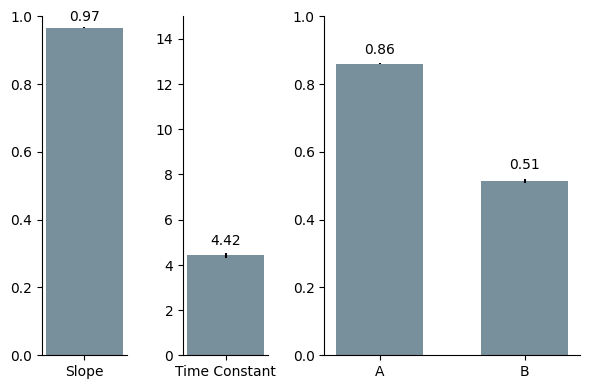

In [11]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

# Define the exponential recovery function
def exp_func(t, A, B, tau):
    return A + (B - A) * np.exp(-t / tau)

# Fit reversal parameters (A, B, tau) for each agent
reversal_params = np.zeros((len(chosen_correct_reversals), 3))
reversal_predictions = np.zeros((len(chosen_correct_reversals), 199))
for i, chosen_ in enumerate(chosen_correct_reversals):
    y = chosen_[301:]    
    t = np.arange(y.size)
    popt, pcov = curve_fit(exp_func, t, y, p0=[y[-1], y[0], 20])
    reversal_params[i] = popt  # [A, B, tau]
    reversal_predictions[i] = exp_func(t, *popt)
# Fit a slope for the psychometric curve for each agent
from sklearn.linear_model import LinearRegression
slopes = np.zeros(len(association_probs[:, -1]))
intercepts = np.zeros(len(association_probs[:, -1]))
for i, asso in enumerate(association_probs[:, -1]):
    lr = LinearRegression()
    X = np.array([0.2, 0.4, 0.6, 0.8]).reshape(-1, 1)
    y = asso
    lr.fit(X, y)
    slopes[i] = lr.coef_[0]
    intercepts[i] = lr.intercept_

n_agents = len(slopes)

color_all = "#607D8B"
color_A = "#607D8B"
color_B = "#A6A6A6"

# Create a gridspec so that the last subplot is twice as big as the first two
from matplotlib import gridspec
fig = plt.figure(figsize=(6, 4))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 3])
axs = [fig.add_subplot(gs[0, i]) for i in range(3)]

# Plot 1: Slope Bar Plot
ax1 = axs[0]
mean_slope = np.mean(slopes)
sem_slope = np.std(slopes, ddof=1) / np.sqrt(n_agents)
bar1 = ax1.bar([0], [mean_slope], yerr=[sem_slope], color=color_all, capsize=0, alpha=0.85, width=0.7)
ax1.text(0, mean_slope + sem_slope + 0.01, f"{mean_slope:.2f}", ha='center', va='bottom', fontsize=10)
ax1.set_xticks([0])
ax1.set_xticklabels(["Slope"])
ax1.set_ylim([0, 1])
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)

# Plot 2: Tau Bar Plot
ax2 = axs[1]
tau_vals = reversal_params[:,2]
mean_tau = np.mean(tau_vals)
sem_tau = np.std(tau_vals, ddof=1) / np.sqrt(n_agents)
bar2 = ax2.bar([0], [mean_tau], yerr=[sem_tau], color=color_all, capsize=0, alpha=0.85, width=0.7)
ax2.text(0, mean_tau + sem_tau + 0.2, f"{mean_tau:.2f}", ha='center', va='bottom', fontsize=10)
ax2.set_xticks([0])
ax2.set_xticklabels(["Time Constant"])
ax2.set_ylim([0, 15])
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Plot 3: Asymptote (A) and Initial (B) on the same plot
ax3 = axs[2]
A_vals = reversal_params[:,0]
B_vals = reversal_params[:,1]
mean_A = np.mean(A_vals)
sem_A = np.std(A_vals, ddof=1) / np.sqrt(n_agents)
mean_B = np.mean(B_vals)
sem_B = np.std(B_vals, ddof=1) / np.sqrt(n_agents)
width = 0.6

ax3.bar([0], [mean_A], yerr=[sem_A], color=color_A, capsize=0, alpha=0.85, width=width, label="Asymptote (A)")
ax3.bar([1], [mean_B], yerr=[sem_B], color=color_A, capsize=0, alpha=0.85, width=width, label="Initial (B)")
ax3.text(0, mean_A + sem_A + 0.02, f"{mean_A:.2f}", ha='center', va='bottom', fontsize=10)
ax3.text(1, mean_B + sem_B + 0.02, f"{mean_B:.2f}", ha='center', va='bottom', fontsize=10)
ax3.set_xticks([0, 1])
ax3.set_xticklabels(["A", "B"])
ax3.set_ylim(0, 1)
ax3.spines['right'].set_visible(False)
ax3.spines['top'].set_visible(False)

plt.tight_layout()
#plt.savefig('figures/WP_optimal_reversal_binary_mars2026_params.pdf')
plt.show()


In [12]:
mean_A

0.8595946089126687

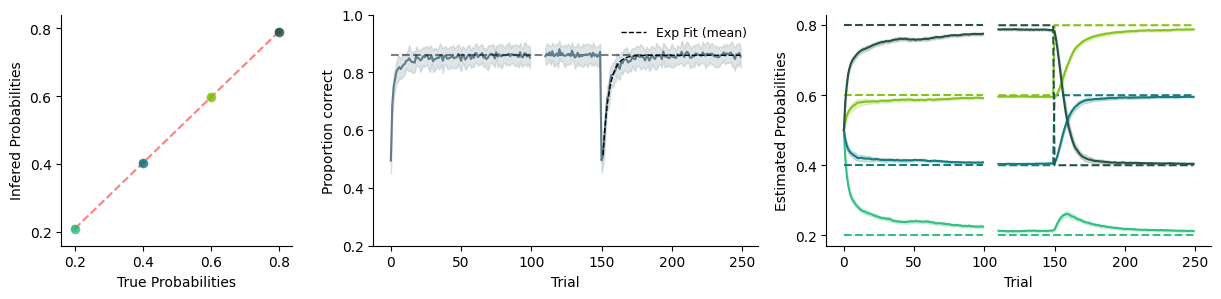

In [13]:
soothing_greens =  ["#34BE82", "#167C80", "#84C318", "#235345"]

fig, axs = plt.subplots(1, 3, figsize=(15, 3), gridspec_kw={'width_ratios': [2, 3, 3]})
pmeans = association_probs[:, -1].mean(axis=0)
pstds = association_probs[:, -1].std(axis=0)
axs[0].scatter(np.array([0.2, 0.4, 0.6, 0.8]), pmeans, alpha=0.7, color=soothing_greens, s=20)
for i, color in enumerate(soothing_greens):
    axs[0].errorbar(np.array([0.2, 0.4, 0.6, 0.8])[i], pmeans[i], yerr=pstds[i], alpha=0.7, color=color, fmt='o')
axs[0].plot([0.2, 0.4, 0.6, 0.8], slopes.mean() * np.array([0.2, 0.4, 0.6, 0.8]) + intercepts.mean(), 'r--', alpha=0.5)
axs[0].set_ylabel('Infered Probabilities')
axs[0].set_xlabel('True Probabilities')
axs[0].set_xlim(0.16, 0.84)
axs[0].set_xticks([0.2, 0.4, 0.6, 0.8])
axs[0].set_ylim(0.16, 0.84)
axs[0].set_yticks([0.2, 0.4, 0.6, 0.8])
axs[0].set_aspect('equal', adjustable='box')
axs[0].spines['right'].set_visible(False)
axs[0].spines['top'].set_visible(False)

# reversal plots of beliefs
mean_correct = chosen_correct_reversals.mean(axis=0)
std_correct = chosen_correct_reversals.std(axis=0)
mean_correct_reversals = chosen_correct_reversals.mean(axis=0)
std_correct_reversals = chosen_correct_reversals.std(axis=0)
xx = np.arange(110, 250)
pmean_correct = mean_correct[:100]
pstd = std_correct[:100]
light_grey = "#607D8B"
axs[1].plot(pmean_correct, color=light_grey)
axs[1].plot( [0, 200], [mean_A, mean_A], 'k--', alpha=0.5)
axs[1].fill_between(np.arange(100), pmean_correct - pstd, pmean_correct + pstd, alpha=0.2, color=light_grey)
axs[1].set_ylabel('Proportion correct')
axs[1].set_xlabel('Trial')

axs[1].plot(xx, mean_correct_reversals[260:400], color=light_grey)
axs[1].fill_between(xx, mean_correct_reversals[260:400] - std_correct_reversals[260:400], mean_correct_reversals[260:400] + std_correct_reversals[260:400], alpha=0.2, color=light_grey)
axs[1].set_xticks([0, 50, 100, 150, 200, 250])
axs[1].set_ylim(0.2, 1.)
axs[1].set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
axs[1].spines['right'].set_visible(False)
axs[1].spines['top'].set_visible(False)

# Plot mean fitted exponential after reversal for the black mean
# Use exp_func(t, A, B, tau) and mean_B, mean_A, mean_tau from previous fit

t_fit = np.arange(151, 250)
exp_curve = exp_func(t_fit - 151, mean_A, mean_B, mean_tau)
axs[1].plot(t_fit, exp_curve[:len(t_fit)], "--", color='black', linewidth=1, label='Exp Fit (mean)')
axs[1].legend(frameon=False, fontsize=9, loc='upper right')

# reversal plots of beliefs
mean_association_probs_reversals = association_probs_reversals.mean(axis=0)
std_association_probs_reversals = association_probs_reversals.std(axis=0)
mean_ground_truth_probas_reversals = ground_truth_probas_reversals.mean(axis=0)
xx = np.arange(110, 250)
for i in range(4):
    pmean = association_probs.mean(axis=0)[:100, i]
    pstd = association_probs.std(axis=0)[:100, i]
    axs[2].plot(pmean, color=soothing_greens[i])
    axs[2].fill_between(np.arange(100), pmean - pstd, pmean + pstd, alpha=0.2, color=soothing_greens[i])
    p = np.array([0.2, 0.4, 0.6, 0.8])[i]
    axs[2].plot(p * np.ones(100), linestyle='--', color=soothing_greens[i])

axs[2].set_ylabel('Estimated Probabilities')
axs[2].set_xlabel('Trial')
for i in range(4):
    axs[2].plot(xx, mean_association_probs_reversals[260:400, i], color=soothing_greens[i])
    axs[2].plot(xx, mean_ground_truth_probas_reversals[260:400, i], linestyle='--', color=soothing_greens[i])
    axs[2].fill_between(xx, 
                        mean_association_probs_reversals[260:400, i] - std_association_probs_reversals[260:400, i], 
                        mean_association_probs_reversals[260:400, i] + std_association_probs_reversals[260:400, i], 
                        alpha=0.2, color=soothing_greens[i])
    axs[2].set_xticks([0, 50, 100, 150, 200, 250])
axs[2].set_ylim(0.17, 0.83)
axs[2].set_yticks([0.2, 0.4, 0.6, 0.8])
axs[2].spines['right'].set_visible(False)
axs[2].spines['top'].set_visible(False)
plt.savefig('figures/WP_optimal_reversal_binary_april2026.pdf')

plt.show()

### With reversals and subjective

In [10]:
# performances as a function of the sequence length
nb_agents = 30
nb_simuls = 100
association_probs = np.zeros((nb_agents, nb_simuls, 500, 4))
chosen_correct = np.zeros((nb_agents, nb_simuls, 500))
association_probs_reversals = np.zeros((nb_agents, nb_simuls, 500, 4))
ground_truth_probas_reversals = np.zeros((nb_agents, nb_simuls, 500, 4))
chosen_correct_reversals = np.zeros((nb_agents, nb_simuls, 500))
itrial = 300

for idx_agent in range(nb_agents):
    # generate data
    np.random.seed(idx_agent)
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=500, num_steps=5, probas=None, variable_length=False, tau=0.0)
    initial_probas = self.env.probas.copy()
    env_probas = np.zeros([nb_simuls, 500, 4])
    for i in range(nb_simuls):
        np.random.seed(i)
        env_probas[i] = self.env.probas[i, 0]
        while True:
            if (env_probas[i, 0] != env_probas[i, -1]).any():
                break
            env_probas[i, itrial:] = env_probas[i, 0][np.random.choice(np.arange(4), replace=False, size=4)]

    np.random.seed(idx_agent)
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=500, num_steps=5, probas=env_probas, variable_length=False)
    all_map_particles, prediction_weather, association_probs_trials, polarity_particles = self.infer(nb_particles=100, w_emission=True, gamma=0.5)
    chosen_correct_reversals[idx_agent] = (np.argmax(prediction_weather, axis=-1) == self.env.correct_weather.numpy())

    # psychometric curve
    np.random.seed(idx_agent)
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=500, num_steps=5, probas=initial_probas, variable_length=False, tau=0.0)
    all_map_particles, prediction_weather, association_probs_trials, polarity_particles = self.infer(nb_particles=100, w_emission=True, gamma=0.5)
    index_sorted = np.argsort(np.unique(self.env.probas, axis=1).squeeze(), axis=1)
    association_probs[idx_agent] = 1 - np.swapaxes(association_probs_trials[np.arange(nb_simuls)[:, None],: , index_sorted], 1, 2)
    chosen_correct[idx_agent] = (np.argmax(prediction_weather, axis=-1) == self.env.correct_weather.numpy())

    # example of a reversal
    env_probas = np.zeros([nb_simuls, 500, 4])
    indexes_sorted = np.zeros([nb_simuls, 4], dtype=int)
    for i in range(nb_simuls):
        np.random.seed(i)
        probas_0 = np.round(self.env.probas[:, 0][i], 1)
        env_probas[i, :itrial] = probas_0
        probas_0_after_reversal = probas_0.copy()
        probas_0_after_reversal[probas_0 == 0.4] = 0.6
        probas_0_after_reversal[probas_0 == 0.6] = 0.8
        probas_0_after_reversal[probas_0 == 0.8] = 0.4
        env_probas[i, itrial:] = probas_0_after_reversal
        indexes_sorted[i] = index_sorted[i]

    self.env.probas = env_probas
    np.random.seed(idx_agent)
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=500, num_steps=5, probas=self.env.probas, variable_length=False)

    all_map_particles, prediction_weather, association_probs_trials, polarity_particles = self.infer(nb_particles=100, w_emission=True, gamma=0.5)
    association_probs_reversals[idx_agent] = 1 - np.swapaxes(association_probs_trials[np.arange(nb_simuls)[:, None], :, indexes_sorted], 1, 2)
    ground_truth_probas_reversals[idx_agent] = np.swapaxes(self.env.probas[np.arange(nb_simuls)[:, None], :, indexes_sorted], 1, 2)

association_probs_reversals = np.mean(association_probs_reversals, axis=1)
ground_truth_probas_reversals = np.mean(ground_truth_probas_reversals, axis=1)
chosen_correct_reversals = np.mean(chosen_correct_reversals, axis=1)

association_probs = np.mean(association_probs, axis=1)
chosen_correct = np.mean(chosen_correct, axis=1)


Inferring: 100%|██████████| 500/500 [11:34<00:00,  1.39s/it]


In [14]:
import pickle
with open("results/WP_optimal_reversal_w_probabilistic_feedback_april2026_params.pkl", "wb") as f:
    pickle.dump([
        association_probs, 
        chosen_correct, 
        association_probs_reversals, 
        ground_truth_probas_reversals, 
        chosen_correct_reversals
    ], f)

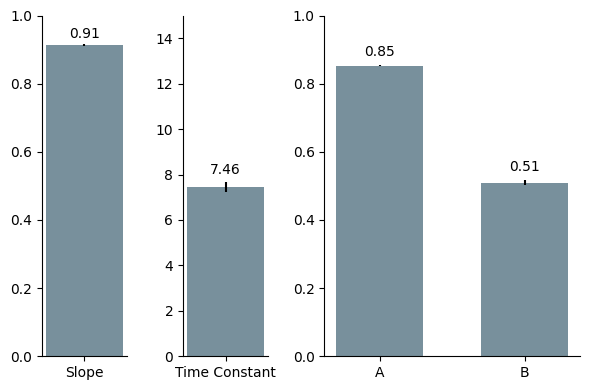

In [15]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

# Define the exponential recovery function
def exp_func(t, A, B, tau):
    return A + (B - A) * np.exp(-t / tau)

# Fit reversal parameters (A, B, tau) for each agent
reversal_params = np.zeros((len(chosen_correct_reversals), 3))
reversal_predictions = np.zeros((len(chosen_correct_reversals), 199))
for i, chosen_ in enumerate(chosen_correct_reversals):
    y = chosen_[301:]    
    t = np.arange(y.size)
    popt, pcov = curve_fit(exp_func, t, y, p0=[y[-1], y[0], 20])
    reversal_params[i] = popt  # [A, B, tau]
    reversal_predictions[i] = exp_func(t, *popt)
# Fit a slope for the psychometric curve for each agent
from sklearn.linear_model import LinearRegression
slopes = np.zeros(len(association_probs[:, -1]))
intercepts = np.zeros(len(association_probs[:, -1]))
for i, asso in enumerate(association_probs[:, -1]):
    lr = LinearRegression()
    X = np.array([0.2, 0.4, 0.6, 0.8]).reshape(-1, 1)
    y = asso
    lr.fit(X, y)
    slopes[i] = lr.coef_[0]
    intercepts[i] = lr.intercept_

n_agents = len(slopes)
A_vals = reversal_params[:,0]
B_vals = reversal_params[:,1]
mean_A = np.mean(A_vals)
sem_A = np.std(A_vals, ddof=1) / np.sqrt(n_agents)
mean_B = np.mean(B_vals)
sem_B = np.std(B_vals, ddof=1) / np.sqrt(n_agents)
width = 0.6


color_all = "#607D8B"
color_A = "#607D8B"
color_B = "#A6A6A6"

# Create a gridspec so that the last subplot is twice as big as the first two
from matplotlib import gridspec
fig = plt.figure(figsize=(6, 4))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 3])
axs = [fig.add_subplot(gs[0, i]) for i in range(3)]

# Plot 1: Slope Bar Plot
ax1 = axs[0]
mean_slope = np.mean(slopes)
sem_slope = np.std(slopes, ddof=1) / np.sqrt(n_agents)
bar1 = ax1.bar([0], [mean_slope], yerr=[sem_slope], color=color_all, capsize=0, alpha=0.85, width=0.7)
ax1.text(0, mean_slope + sem_slope + 0.01, f"{mean_slope:.2f}", ha='center', va='bottom', fontsize=10)
ax1.set_xticks([0])
ax1.set_xticklabels(["Slope"])
ax1.set_ylim([0, 1])
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)

# Plot 2: Tau Bar Plot
ax2 = axs[1]
tau_vals = reversal_params[:,2]
mean_tau = np.mean(tau_vals)
sem_tau = np.std(tau_vals, ddof=1) / np.sqrt(n_agents)
bar2 = ax2.bar([0], [mean_tau], yerr=[sem_tau], color=color_all, capsize=0, alpha=0.85, width=0.7)
ax2.text(0, mean_tau + sem_tau + 0.2, f"{mean_tau:.2f}", ha='center', va='bottom', fontsize=10)
ax2.set_xticks([0])
ax2.set_xticklabels(["Time Constant"])
ax2.set_ylim([0, 15])
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Plot 3: Asymptote (A) and Initial (B) on the same plot
ax3 = axs[2]

ax3.bar([0], [mean_A], yerr=[sem_A], color=color_A, capsize=0, alpha=0.85, width=width, label="Asymptote (A)")
ax3.bar([1], [mean_B], yerr=[sem_B], color=color_A, capsize=0, alpha=0.85, width=width, label="Initial (B)")
ax3.text(0, mean_A + sem_A + 0.02, f"{mean_A:.2f}", ha='center', va='bottom', fontsize=10)
ax3.text(1, mean_B + sem_B + 0.02, f"{mean_B:.2f}", ha='center', va='bottom', fontsize=10)
ax3.set_xticks([0, 1])
ax3.set_xticklabels(["A", "B"])
ax3.set_ylim(0, 1)
ax3.spines['right'].set_visible(False)
ax3.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/WP_optimal_reversal_w_probabilistic_feedback_april2026_params.pdf')
plt.show()


In [17]:
self.env.probas 

array([[[0.8, 0.2, 0.4, 0.6],
        [0.8, 0.2, 0.4, 0.6],
        [0.8, 0.2, 0.4, 0.6],
        ...,
        [0.4, 0.2, 0.6, 0.8],
        [0.4, 0.2, 0.6, 0.8],
        [0.4, 0.2, 0.6, 0.8]],

       [[0.8, 0.4, 0.2, 0.6],
        [0.8, 0.4, 0.2, 0.6],
        [0.8, 0.4, 0.2, 0.6],
        ...,
        [0.4, 0.6, 0.2, 0.8],
        [0.4, 0.6, 0.2, 0.8],
        [0.4, 0.6, 0.2, 0.8]],

       [[0.4, 0.6, 0.2, 0.8],
        [0.4, 0.6, 0.2, 0.8],
        [0.4, 0.6, 0.2, 0.8],
        ...,
        [0.6, 0.8, 0.2, 0.4],
        [0.6, 0.8, 0.2, 0.4],
        [0.6, 0.8, 0.2, 0.4]],

       ...,

       [[0.6, 0.4, 0.2, 0.8],
        [0.6, 0.4, 0.2, 0.8],
        [0.6, 0.4, 0.2, 0.8],
        ...,
        [0.8, 0.6, 0.2, 0.4],
        [0.8, 0.6, 0.2, 0.4],
        [0.8, 0.6, 0.2, 0.4]],

       [[0.2, 0.8, 0.6, 0.4],
        [0.2, 0.8, 0.6, 0.4],
        [0.2, 0.8, 0.6, 0.4],
        ...,
        [0.2, 0.4, 0.8, 0.6],
        [0.2, 0.4, 0.8, 0.6],
        [0.2, 0.4, 0.8, 0.6]],

       [[0.6

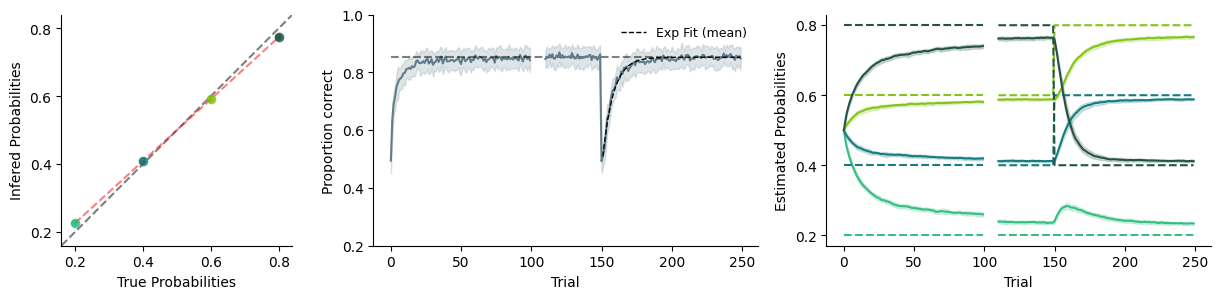

In [16]:
soothing_greens =  ["#34BE82", "#167C80", "#84C318", "#235345"]

fig, axs = plt.subplots(1, 3, figsize=(15, 3), gridspec_kw={'width_ratios': [2, 3, 3]})
pmeans = association_probs[:, -1].mean(axis=0)
pstds = association_probs[:, -1].std(axis=0)
axs[0].scatter(np.array([0.2, 0.4, 0.6, 0.8]), pmeans, alpha=0.7, color=soothing_greens, s=20)
for i, color in enumerate(soothing_greens):
    axs[0].errorbar(np.array([0.2, 0.4, 0.6, 0.8])[i], pmeans[i], yerr=pstds[i], alpha=0.7, color=color, fmt='o')
axs[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='x=y')
axs[0].set_ylabel('Infered Probabilities')
axs[0].set_xlabel('True Probabilities')
axs[0].set_xlim(0.16, 0.84)
axs[0].set_xticks([0.2, 0.4, 0.6, 0.8])
axs[0].set_ylim(0.16, 0.84)
axs[0].set_yticks([0.2, 0.4, 0.6, 0.8])
axs[0].set_aspect('equal', adjustable='box')
axs[0].spines['right'].set_visible(False)
axs[0].spines['top'].set_visible(False)
axs[0].plot([0.2, 0.4, 0.6, 0.8], slopes.mean() * np.array([0.2, 0.4, 0.6, 0.8]) + intercepts.mean(), 'r--', alpha=0.5)

# reversal plots of beliefs
mean_correct = chosen_correct.mean(axis=0)
std_correct = chosen_correct.std(axis=0)
mean_correct_reversals = chosen_correct_reversals.mean(axis=0)
std_correct_reversals = chosen_correct_reversals.std(axis=0)
xx = np.arange(110, 250)
pmean_correct = mean_correct[:100]
pstd = std_correct[:100]
light_grey = "#607D8B"
axs[1].plot(pmean_correct, color=light_grey)
axs[1].plot( [0, 200], [mean_A, mean_A], 'k--', alpha=0.5)
axs[1].fill_between(np.arange(100), pmean_correct - pstd, pmean_correct + pstd, alpha=0.2, color=light_grey)
axs[1].set_ylabel('Proportion correct')
axs[1].set_xlabel('Trial')
axs[1].plot(xx, mean_correct_reversals[260:400], color=light_grey)
axs[1].fill_between(xx, mean_correct_reversals[260:400] - std_correct_reversals[260:400], mean_correct_reversals[260:400] + std_correct_reversals[260:400], alpha=0.2, color=light_grey)
axs[1].set_xticks([0, 50, 100, 150, 200, 250])
axs[1].set_ylim(0.2, 1.)
axs[1].set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
axs[1].spines['right'].set_visible(False)
axs[1].spines['top'].set_visible(False)

# Plot mean fitted exponential after reversal for the black mean
# Use exp_func(t, A, B, tau) and mean_B, mean_A, mean_tau from previous fit
if 'mean_A' in locals() and 'mean_B' in locals() and 'mean_tau' in locals():
    t_fit = np.arange(151, 250)
    exp_curve = exp_func(t_fit - 151, mean_A, mean_B, mean_tau)
    axs[1].plot(t_fit, exp_curve[:len(t_fit)], "--", color='black', linewidth=1, label='Exp Fit (mean)')
    axs[1].legend(frameon=False, fontsize=9, loc='upper right')
    
# reversal plots of beliefs
mean_association_probs_reversals = association_probs_reversals.mean(axis=0)
std_association_probs_reversals = association_probs_reversals.std(axis=0)
mean_ground_truth_probas_reversals = ground_truth_probas_reversals.mean(axis=0)
xx = np.arange(110, 250)
for i in range(4):
    pmean = association_probs.mean(axis=0)[:100, i]
    pstd = association_probs.std(axis=0)[:100, i]
    axs[2].plot(pmean, color=soothing_greens[i])
    axs[2].fill_between(np.arange(100), pmean - pstd, pmean + pstd, alpha=0.2, color=soothing_greens[i])
    p = np.array([0.2, 0.4, 0.6, 0.8])[i]
    axs[2].plot(p * np.ones(100), linestyle='--', color=soothing_greens[i])
axs[2].set_ylabel('Estimated Probabilities')
axs[2].set_xlabel('Trial')
for i in range(4):
    axs[2].plot(xx, mean_association_probs_reversals[260:400, i], color=soothing_greens[i])
    axs[2].plot(xx, mean_ground_truth_probas_reversals[260:400, i], linestyle='--', color=soothing_greens[i])
    axs[2].fill_between(xx, 
                        mean_association_probs_reversals[260:400, i] - std_association_probs_reversals[260:400, i], 
                        mean_association_probs_reversals[260:400, i] + std_association_probs_reversals[260:400, i], 
                        alpha=0.2, color=soothing_greens[i])
    axs[2].set_xticks([0, 50, 100, 150, 200, 250])
axs[2].set_ylim(0.17, 0.83)
axs[2].set_yticks([0.2, 0.4, 0.6, 0.8])
axs[2].spines['right'].set_visible(False)
axs[2].spines['top'].set_visible(False)
plt.savefig('figures/WP_optimal_reversal_w_probabilistic_feedback_april2026.pdf')

plt.show()

### Performance

In [ ]:
from learn_to_infer import Worker
from task import probabilistic_task
import pandas as pd
import torch
import numpy as np
from matplotlib import pyplot as plt
from WP.optimality_legacy import Optimality
import numpy as np
from task import probabilistic_task

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


In [28]:
# performances as a function of the sequence length
nb_agents = 30
nb_simuls = 1000
performances_optimal = np.zeros((nb_agents, nb_simuls))

self = Optimality(
    probabilistic_task(),
)

for idx_agent in range(nb_agents):
    # 3 steps
    self.env.probas = None
    np.random.seed(idx_agent)
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=100, num_steps=5, probas=None)

    all_map_particles, prediction_weather, _ = self.infer(nb_particles=200, w_emission=True, gamma=0.5)
    performances_optimal[idx_agent] = (np.argmax(prediction_weather, axis=-1) == self.env.correct_weather.numpy()).mean(axis=1)

Inferring: 100%|██████████| 100/100 [04:37<00:00,  2.78s/it]


In [26]:
(np.argmax(prediction_weather, axis=-1) == self.env.correct_weather.numpy()).mean(axis=1).shape

(1000,)

In [4]:
# performances as a function of the sequence length
nb_agents = 30
nb_simuls = 500

self = Optimality(
    probabilistic_task(),
)


# 3 steps
self.env.probas = None
np.random.seed(1)
self.env.generate_test_task(num_tasks=nb_simuls, num_trials=200, num_steps=5, probas=None, ffs=[0.3] * nb_simuls)

all_map_particles, prediction_weather, _ = self.infer(nb_particles=200, w_emission=True, gamma=0.5)
performances_optimal_ = (np.argmax(prediction_weather, axis=-1) == self.env.correct_weather.numpy()).mean(axis=1)

Inferring: 100%|██████████| 200/200 [06:09<00:00,  1.85s/it]


In [6]:
performances_optimal_.mean()

0.66424

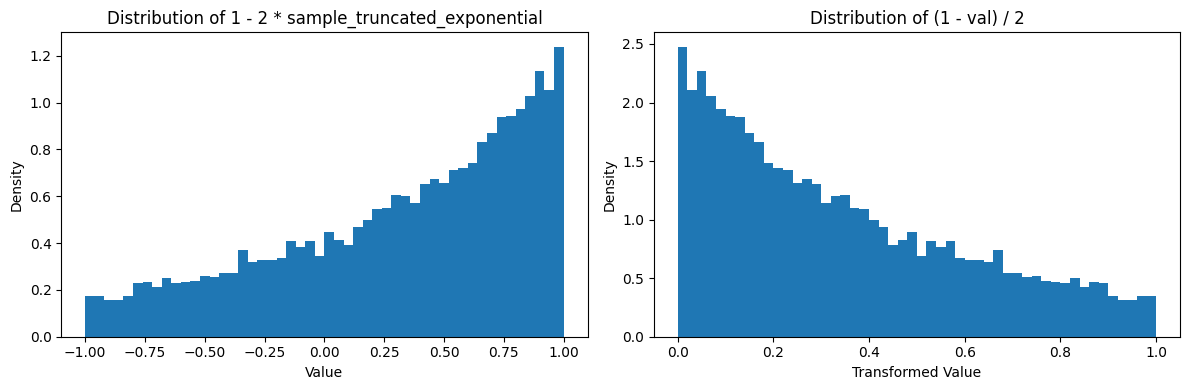

In [50]:
from task import sample_truncated_exponential
import matplotlib.pyplot as plt

vals = 1 - 2 * sample_truncated_exponential(size=10000, lambda_param=2, ub=1.0)
vals_transformed = (1 - vals) / 2

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Original distribution
axs[0].hist(vals, bins=50, density=True)
axs[0].set_title("Distribution of 1 - 2 * sample_truncated_exponential")
axs[0].set_xlabel("Value")
axs[0].set_ylabel("Density")

# Transformed distribution
axs[1].hist(vals_transformed, bins=50, density=True)
axs[1].set_title("Distribution of (1 - val) / 2")
axs[1].set_xlabel("Transformed Value")
axs[1].set_ylabel("Density")

plt.tight_layout()
plt.show()